# Step 2c — CDAN-E: Class-Conditional DANN + Entropy

**Upgrades from DANN v2 (target F1=0.395):**

| Change | Why |
|---|---|
| Domain discriminator input: 128-d → **768-d outer product** | Conditions discrimination on class predictions — aligns per-class rather than globally |
| Discriminator: Dense(512)→Dense(256)→Dense(1) | Deeper to handle 768-d input |
| Entropy minimisation on target (λ=0.1 ramped) | Encourages confident predictions without target labels |
| domain_loss_weight 0.3 → **0.5** | Harder discrimination problem needs more signal |

**Architecture unchanged:** Encoder Dense(512)→LN→Dense(256)→LN→Dense(128), Label predictor Dense(64)→Dense(6), GRL, λ schedule, CORAL, label smoothing, gradient clipping.

In [1]:
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

tf.random.set_seed(42)
np.random.seed(42)

PROJECT_ROOT = Path.cwd().parent.parent if Path.cwd().name == 'step2_dann' else Path.cwd()
RESULTS_DIR  = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)
print('Project root:', PROJECT_ROOT)
print('TF:', tf.__version__)

Project root: /Users/kirtan/Projects /NNDL
TF: 2.21.0


## 1. Data + CORAL

In [2]:
X_train = np.load(PROJECT_ROOT / 'step3_X_train.npy').astype(np.float32)
y_train = np.load(PROJECT_ROOT / 'step3_y_train.npy').astype(np.int64)
X_test  = np.load(PROJECT_ROOT / 'step3_X_test.npy').astype(np.float32)
y_test  = np.load(PROJECT_ROOT / 'step3_y_test.npy').astype(np.int64)

with open(PROJECT_ROOT / 'step3_label_mapping.json') as f:
    label_map = json.load(f)
class_names = [label_map[str(i)] for i in range(len(label_map))]
n_classes   = len(class_names)

X_target_raw = np.load(PROJECT_ROOT / 'gse126030_preprocessed.npy').astype(np.float32)
df_labels    = pd.read_csv(PROJECT_ROOT / 'improvements/1_label_validation/label_validation_output/gse126030_reclustered_labels.csv')
mask         = (df_labels['confidence'] >= 0.55) & (df_labels['new_class'] != 'Uncertain')
y_target_eval = np.array([class_names.index(n) for n in df_labels.loc[mask, 'new_class']], dtype=np.int64)

classes, counts = np.unique(y_train, return_counts=True)
class_weight = {int(c): len(y_train) / (n_classes * cnt) for c, cnt in zip(classes, counts)}

def coral_align(X_src, X_tgt, reg=1e-3):
    src_mean = X_src.mean(axis=0)
    Xs = X_src - src_mean; Xt = X_tgt - X_tgt.mean(axis=0)
    Cs = (Xs.T@Xs)/(Xs.shape[0]-1)+reg*np.eye(Xs.shape[1])
    Ct = (Xt.T@Xt)/(Xt.shape[0]-1)+reg*np.eye(Xt.shape[1])
    def msqrt(M):  v,V=np.linalg.eigh(M); return V@np.diag(np.sqrt(np.maximum(v,0)))@V.T
    def minsqrt(M):v,V=np.linalg.eigh(M); return V@np.diag(1/np.sqrt(np.maximum(v,1e-10)))@V.T
    return ((Xt@(minsqrt(Ct)@msqrt(Cs)))+src_mean).astype(np.float32)

print('Running CORAL...')
X_target_coral = coral_align(X_train, X_target_raw)
X_target_eval  = X_target_coral[mask.values]
print(f'Train:{X_train.shape}  Target eval:{X_target_eval.shape}')

Running CORAL...
Train:(6824, 3000)  Target eval:(12776, 3000)


## 2. CDAN-E Model

Key change: the domain discriminator receives the **outer product** of encoder features f (128-d) and classifier predictions ŷ (6-d), producing a 768-d class-conditional representation. This conditions domain discrimination per class rather than globally.

In [3]:
class GradientReversalLayer(keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.lambda_val = tf.Variable(0.0, trainable=False, dtype=tf.float32)

    def call(self, x):
        lam = self.lambda_val
        @tf.custom_gradient
        def _rev(x):
            return x, lambda dy: -lam * dy
        return _rev(x)


def build_encoder(input_dim):
    inp = keras.Input(shape=(input_dim,))
    x = layers.Dense(512, activation='relu')(inp)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    return keras.Model(inp, x, name='encoder')


def build_label_predictor(latent_dim, n_classes):
    inp = keras.Input(shape=(latent_dim,))
    x   = layers.Dense(64, activation='relu')(inp)
    x   = layers.Dropout(0.2)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    return keras.Model(inp, out, name='label_predictor')


def build_domain_discriminator(cond_dim):
    # Wider+deeper to handle 768-d conditioning input
    inp = keras.Input(shape=(cond_dim,))
    x   = layers.Dense(512, activation='relu')(inp)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(256, activation='relu')(x)
    x   = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inp, out, name='domain_discriminator')


print('Components defined.')

Components defined.


In [4]:
class CDANEModel(keras.Model):
    def __init__(self, encoder, label_predictor, domain_discriminator, grl,
                 domain_loss_weight=0.5, label_smoothing=0.1,
                 max_ent_weight=0.1, ent_ramp_epochs=10,
                 class_weight_dict=None, **kwargs):
        super().__init__(**kwargs)
        self.encoder              = encoder
        self.label_predictor      = label_predictor
        self.domain_discriminator = domain_discriminator
        self.grl                  = grl
        self.domain_loss_weight   = domain_loss_weight
        self.label_smoothing      = label_smoothing
        self.max_ent_weight       = max_ent_weight
        self.ent_ramp_epochs      = tf.constant(float(ent_ramp_epochs), dtype=tf.float32)
        self.current_epoch        = tf.Variable(0.0, trainable=False, dtype=tf.float32)

        if class_weight_dict:
            cw = np.array([class_weight_dict[i] for i in range(len(class_weight_dict))], dtype=np.float32)
            self.cw_tensor = tf.constant(cw)
        else:
            self.cw_tensor = None

        self.loss_t   = keras.metrics.Mean(name='loss')
        self.ce_t     = keras.metrics.Mean(name='class_loss')
        self.dom_t    = keras.metrics.Mean(name='domain_loss')
        self.ent_t    = keras.metrics.Mean(name='ent_loss')
        self.acc_t    = keras.metrics.SparseCategoricalAccuracy(name='class_acc')
        self.dacc_t   = keras.metrics.BinaryAccuracy(name='domain_acc')

    def call(self, x, training=False):
        z = self.encoder(x, training=training)
        return self.label_predictor(z, training=training)

    def _outer_product(self, f, y_hat):
        """Compute multilinear conditioning: (batch,128) x (batch,6) -> (batch,768)."""
        outer = tf.einsum('bi,bj->bij', f, y_hat)          # (batch, 128, 6)
        return tf.reshape(outer, [tf.shape(f)[0], -1])     # (batch, 768)

    def train_step(self, data):
        (src_x, src_y), (tgt_x,) = data
        batch = tf.shape(src_x)[0]
        smooth = self.label_smoothing
        d_src = tf.fill((batch, 1), smooth)
        d_tgt = tf.fill((batch, 1), 1.0 - smooth)

        # Entropy weight ramp
        ent_progress = tf.minimum(self.current_epoch / self.ent_ramp_epochs, 1.0)
        ent_weight   = self.max_ent_weight * ent_progress

        with tf.GradientTape() as tape:
            f_src  = self.encoder(src_x, training=True)
            f_tgt  = self.encoder(tgt_x, training=True)
            y_src  = self.label_predictor(f_src, training=True)
            y_tgt  = self.label_predictor(f_tgt, training=True)

            # CE loss with class weights
            per_s = keras.losses.sparse_categorical_crossentropy(src_y, y_src)
            if self.cw_tensor is not None:
                ce_loss = tf.reduce_mean(per_s * tf.gather(self.cw_tensor, src_y))
            else:
                ce_loss = tf.reduce_mean(per_s)

            # Class-conditional outer product conditioning
            cond_src = self._outer_product(self.grl(f_src), y_src)
            cond_tgt = self._outer_product(self.grl(f_tgt), y_tgt)
            d_pred_src = self.domain_discriminator(cond_src, training=True)
            d_pred_tgt = self.domain_discriminator(cond_tgt, training=True)

            domain_loss = (
                tf.reduce_mean(keras.losses.binary_crossentropy(d_src, d_pred_src)) +
                tf.reduce_mean(keras.losses.binary_crossentropy(d_tgt, d_pred_tgt))
            )

            # Entropy minimisation on target
            ent_loss = -tf.reduce_mean(
                tf.reduce_sum(y_tgt * tf.math.log(y_tgt + 1e-8), axis=1)
            )

            total = ce_loss + self.domain_loss_weight * domain_loss + ent_weight * ent_loss

        grads = tape.gradient(total, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        d_both    = tf.concat([d_src, d_tgt], axis=0)
        dpred_both = tf.concat([d_pred_src, d_pred_tgt], axis=0)
        self.loss_t.update_state(total)
        self.ce_t.update_state(ce_loss)
        self.dom_t.update_state(domain_loss)
        self.ent_t.update_state(ent_loss)
        self.acc_t.update_state(src_y, y_src)
        self.dacc_t.update_state(d_both, dpred_both)
        return {'loss': self.loss_t.result(), 'class_loss': self.ce_t.result(),
                'domain_loss': self.dom_t.result(), 'ent_loss': self.ent_t.result(),
                'class_acc': self.acc_t.result(), 'domain_acc': self.dacc_t.result()}

    def test_step(self, data):
        x, y = data
        y_pred = self(x, training=False)
        loss = tf.reduce_mean(keras.losses.sparse_categorical_crossentropy(y, y_pred))
        self.ce_t.update_state(loss)
        self.acc_t.update_state(y, y_pred)
        return {'class_loss': self.ce_t.result(), 'class_acc': self.acc_t.result()}

    @property
    def metrics(self):
        return [self.loss_t, self.ce_t, self.dom_t, self.ent_t, self.acc_t, self.dacc_t]

print('CDANEModel defined.')

CDANEModel defined.


## 3. Instantiate + Datasets + Callbacks

In [5]:
BATCH_SIZE         = 128
LEARNING_RATE      = 2e-4
DOMAIN_LOSS_WEIGHT = 0.5      # increased from v2's 0.3
MAX_EPOCHS         = 100
PATIENCE           = 15
ENT_RAMP_EPOCHS    = 10
LATENT_DIM         = 128
COND_DIM           = LATENT_DIM * n_classes   # 128 * 6 = 768

grl             = GradientReversalLayer(name='grl')
encoder         = build_encoder(X_train.shape[1])
label_predictor = build_label_predictor(LATENT_DIM, n_classes)
domain_disc     = build_domain_discriminator(COND_DIM)

model = CDANEModel(
    encoder=encoder, label_predictor=label_predictor,
    domain_discriminator=domain_disc, grl=grl,
    domain_loss_weight=DOMAIN_LOSS_WEIGHT,
    label_smoothing=0.1, max_ent_weight=0.1,
    ent_ramp_epochs=ENT_RAMP_EPOCHS,
    class_weight_dict=class_weight,
    name='CDAN_E'
)
model.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE, clipnorm=1.0))

src_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(10000, seed=42).batch(BATCH_SIZE, drop_remainder=True)
)
tgt_ds = (
    tf.data.Dataset.from_tensor_slices((X_target_coral,))
    .shuffle(100000, seed=42).batch(BATCH_SIZE, drop_remainder=True).repeat()
)
train_ds = tf.data.Dataset.zip((src_ds, tgt_ds))
val_ds   = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE)

class DANNLambdaScheduler(keras.callbacks.Callback):
    def __init__(self, grl_layer, total_epochs, ent_ramp):
        super().__init__()
        self.grl = grl_layer
        self.total = total_epochs
        self.ent_ramp = ent_ramp
    def on_epoch_begin(self, epoch, logs=None):
        p   = epoch / self.total
        lam = 2.0 / (1.0 + np.exp(-10.0 * p)) - 1.0
        self.grl.lambda_val.assign(lam)
        self.model.current_epoch.assign(float(epoch))
    def on_epoch_end(self, epoch, logs=None):
        if (epoch+1) % 10 == 0:
            lam = float(self.grl.lambda_val.numpy())
            print(f'  [λ={lam:.3f}]', end='')

callbacks = [
    DANNLambdaScheduler(grl, MAX_EPOCHS, ENT_RAMP_EPOCHS),
    keras.callbacks.EarlyStopping(
        monitor='val_class_loss', mode='min',
        patience=PATIENCE, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_class_loss', mode='min',
        factor=0.5, patience=7, min_lr=1e-6, verbose=1
    ),
]
print(f'Steps/epoch: {len(src_ds)}  |  Conditioning dim: {COND_DIM}')

Steps/epoch: 53  |  Conditioning dim: 768


## 4. Training

In [6]:
history = model.fit(
    train_ds, epochs=MAX_EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks, verbose=1
)

Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - class_acc: 0.3395 - class_loss: 1.6336 - domain_acc: 0.0000e+00 - domain_loss: 1.3916 - ent_loss: 1.4255 - loss: 2.3294 - val_class_acc: 0.6553 - val_class_loss: 0.9774 - learning_rate: 2.0000e-04
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - class_acc: 0.6772 - class_loss: 0.8739 - domain_acc: 0.0000e+00 - domain_loss: 1.3682 - ent_loss: 1.1589 - loss: 1.5696 - val_class_acc: 0.7737 - val_class_loss: 0.6248 - learning_rate: 2.0000e-04
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - class_acc: 0.8208 - class_loss: 0.5105 - domain_acc: 0.0000e+00 - domain_loss: 1.3322 - ent_loss: 0.8931 - loss: 1.1945 - val_class_acc: 0.8277 - val_class_loss: 0.5060 - learning_rate: 2.0000e-04
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - class_acc: 0.8822 - class_loss: 0.3362 - domain_acc: 0.0000e+00 - domain_loss: 1.2938 - ent_loss: 0.7177 - loss: 1.0046 - val_class_acc: 0.8581 - val_class_loss: 0.4410 - learning_rate: 2.0000e

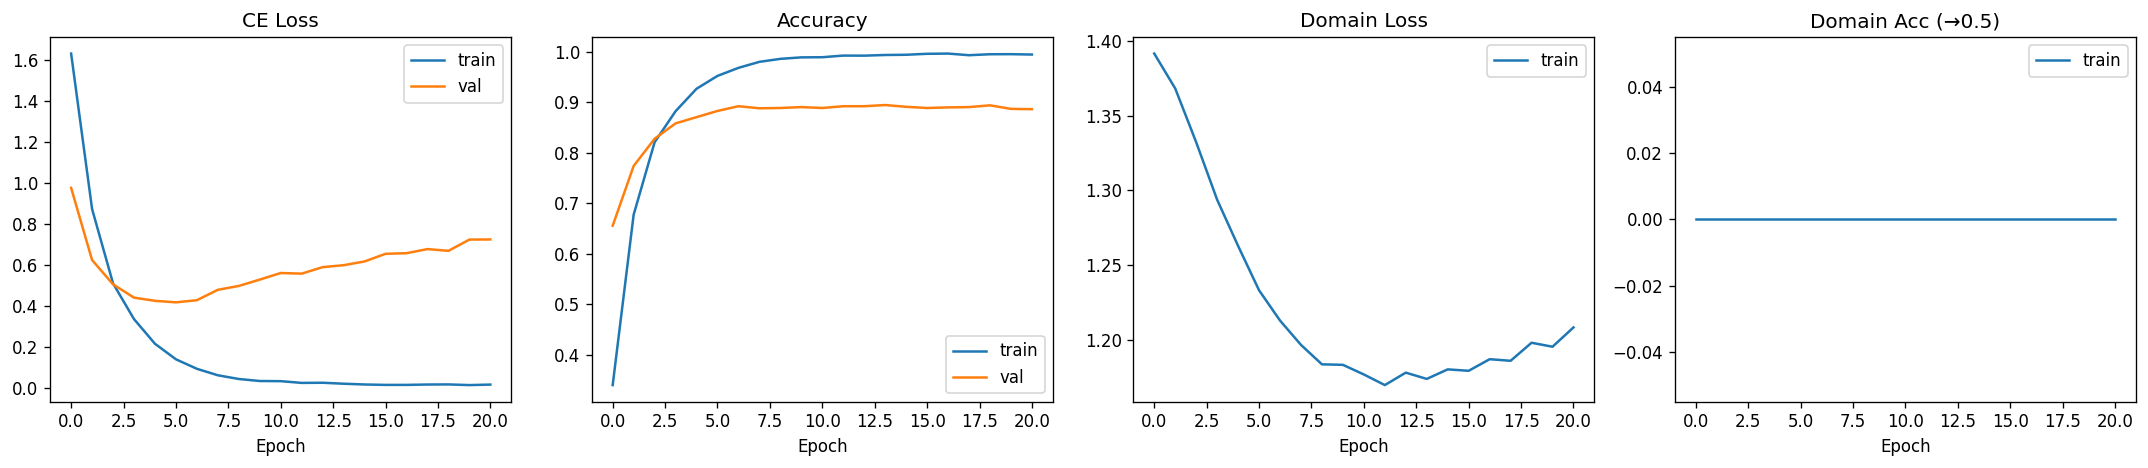

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, k, t in [
    (axes[0], 'class_loss',  'CE Loss'),
    (axes[1], 'class_acc',   'Accuracy'),
    (axes[2], 'domain_loss', 'Domain Loss'),
    (axes[3], 'domain_acc',  'Domain Acc (→0.5)'),
]:
    ax.plot(history.history[k], label='train')
    if f'val_{k}' in history.history:
        ax.plot(history.history[f'val_{k}'], label='val')
    ax.set_title(t); ax.set_xlabel('Epoch'); ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves_cdan.png', bbox_inches='tight')
plt.show()

## 5. Evaluation

In [8]:
y_pred_src = np.argmax(model.predict(X_test,        batch_size=BATCH_SIZE), axis=1)
y_pred_tgt = np.argmax(model.predict(X_target_eval, batch_size=BATCH_SIZE), axis=1)
src_f1 = f1_score(y_test,        y_pred_src, average='macro')
tgt_f1 = f1_score(y_target_eval, y_pred_tgt, average='macro')
print(f'Source F1: {src_f1:.4f}   Target F1: {tgt_f1:.4f}')
print('\n--- Source ---')
print(classification_report(y_test, y_pred_src, target_names=class_names))
print('\n--- Target ---')
print(classification_report(y_target_eval, y_pred_tgt, target_names=class_names))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Source F1: 0.8722   Target F1: 0.3892

--- Source ---
              precision    recall  f1-score   support

    Effector       0.93      0.93      0.93       482
   Exhausted       0.85      0.96      0.90       166
       Naive       0.79      0.88      0.83       224
   Other_CD4       0.84      0.76      0.80       321
    Th1-like       0.88      0.82      0.85       141
        Treg       0.94      0.92      0.93       372

    accuracy                           0.88      1706
   macro avg       0.87      0.88      0.87      1706
weighted avg       0.88      0.88      0.88      1706


--- Target ---
              precision    recall  f1-score   support

    Effector       0.57      0.52      0.54      2839
   Exhausted       0.06      0.10      0.07       903
       Naive       0.83      0.53      0.65      3806
   Other_CD4       0.38      0.32      0.35      2127
    Th1-like       0.17      0.21   

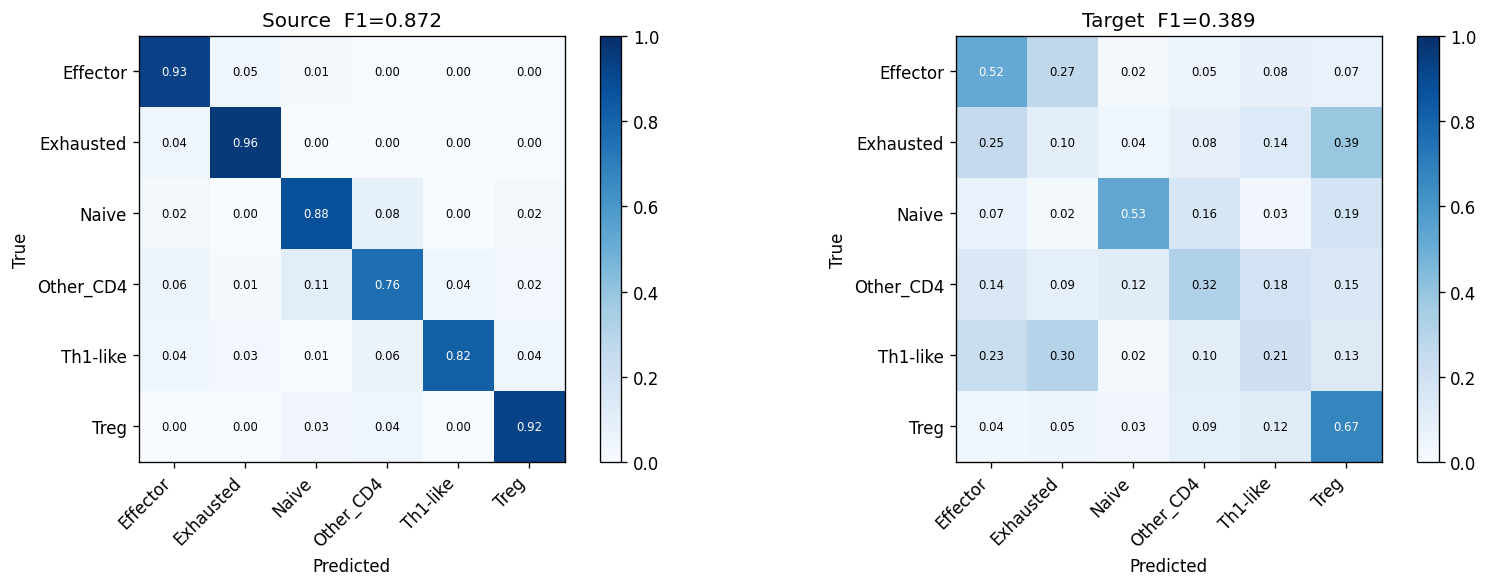

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_true, y_pred, title in [
    (axes[0], y_test,        y_pred_src, f'Source  F1={src_f1:.3f}'),
    (axes[1], y_target_eval, y_pred_tgt, f'Target  F1={tgt_f1:.3f}'),
]:
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xticks(range(n_classes)); ax.set_yticks(range(n_classes))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for i in range(n_classes):
        for j in range(n_classes):
            ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center',
                    color='white' if cm[i,j]>0.5 else 'black', fontsize=7)
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices_cdan.png', bbox_inches='tight')
plt.show()

## 6. Save + Comparison

In [10]:
src_rep = classification_report(y_test,        y_pred_src, target_names=class_names, output_dict=True)
tgt_rep = classification_report(y_target_eval, y_pred_tgt, target_names=class_names, output_dict=True)
results = {
    'model': 'CDAN_E',
    'config': {
        'cond_dim': COND_DIM, 'domain_loss_weight': DOMAIN_LOSS_WEIGHT,
        'ent_ramp_epochs': ENT_RAMP_EPOCHS, 'coral': True,
        'epochs_trained': len(history.history['class_loss']),
    },
    'source_test': {'macro_f1': src_f1, 'accuracy': accuracy_score(y_test, y_pred_src),
                    'per_class_f1': {c: src_rep[c]['f1-score'] for c in class_names}},
    'target_eval': {'macro_f1': tgt_f1, 'accuracy': accuracy_score(y_target_eval, y_pred_tgt),
                    'per_class_f1': {c: tgt_rep[c]['f1-score'] for c in class_names}},
}
with open(RESULTS_DIR / 'cdan_e_results.json', 'w') as f:
    json.dump(results, f, indent=2)
encoder.save(str(RESULTS_DIR / 'cdan_encoder.keras'))
label_predictor.save(str(RESULTS_DIR / 'cdan_predictor.keras'))

all_models = [
    ('GeneAtt v2 (CORAL+MMD)', 0.893, 0.404),
    ('DANN v2',                0.875, 0.395),
    ('VAE + Classifier',       0.881, 0.383),
    ('PatchTransformer',       0.772, 0.384),
    ('CDAN-E',                 src_f1, tgt_f1),
]
best = max(t for _,_,t in all_models)
print(f'\n{"Model":28s} {"Source F1":>10s} {"Target F1":>10s}')
print('-'*52)
for name, sf, tf_ in all_models:
    mark = ' ◄ best' if tf_ == best else ''
    print(f'{name:28s} {sf:10.3f} {tf_:10.3f}{mark}')


Model                         Source F1  Target F1
----------------------------------------------------
GeneAtt v2 (CORAL+MMD)            0.893      0.404 ◄ best
DANN v2                           0.875      0.395
VAE + Classifier                  0.881      0.383
PatchTransformer                  0.772      0.384
CDAN-E                            0.872      0.389
